<a href="https://colab.research.google.com/github/edwardcalvinvazc-maker/MLSamples/blob/main/Imputer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [107]:
import pandas as pd
df = pd.read_csv('/content/synthetic_dataset.csv')

In [108]:
df

,Category,Price,Rating,Stock,Discount
0,NaN,5548.0,1.870322,NaN,0.0
1,NaN,3045.0,4.757798,NaN,38.0
2,NaN,4004.0,NaN,In Stock,0.0
3,NaN,4808.0,1.492085,NaN,33.0
4,NaN,1817.0,NaN,Out of Stock,23.0
...,...,...,...,...,...
4357,NaN,4436.0,4.728335,NaN,49.0
4358,B,6236.0,NaN,Out of Stock,4.0
4359,NaN,3283.0,NaN,Out of Stock,9.0
4360,D,2999.0,4.425995,NaN,40.0


In [109]:
missing_values_count = df.isnull().sum()
display(missing_values_count)

,0
Category,2748
Price,174
Rating,2050
Stock,1352
Discount,392


In [110]:
from sklearn.experimental import enable_iterative_imputer  # noqa
# now you can import normally from sklearn.impute
from sklearn.impute import IterativeImputer

In [111]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder

# 1. Prepare a copy and encode categorical columns into numbers
df_encoded = df.copy()
label_mappings = {}

# Identify categorical (object) columns
cat_cols = df_encoded.select_dtypes(include=['object']).columns

for col in cat_cols:
    # We only fit on non-null values so NaNs stay as NaNs for the imputer
    le = LabelEncoder()
    mask = df_encoded[col].notnull()
    df_encoded.loc[mask, col] = le.fit_transform(df_encoded.loc[mask, col].astype(str))
    df_encoded[col] = df_encoded[col].astype(float)
    label_mappings[col] = le

# 2. Run IterativeImputer on the numerical data
imp_mean = IterativeImputer(random_state=0)
data_imputed = imp_mean.fit_transform(df_encoded)

# 3. Reconstruct the DataFrame and decode categorical values back to strings
df_final = pd.DataFrame(data_imputed, columns=df.columns)

for col, le in label_mappings.items():
    # Round to nearest integer index and transform back to label
    df_final[col] = le.inverse_transform(df_final[col].round().astype(int))

print("--- Imputation Successful ---")
print(df_final.head())
df_final

--- Imputation Successful ---
  Category   Price    Rating         Stock  Discount
0        C  5548.0  1.870322  Out of Stock       0.0
1        C  3045.0  4.757798      In Stock      38.0
2        C  4004.0  3.019648      In Stock       0.0
3        C  4808.0  1.492085      In Stock      33.0
4        B  1817.0  3.010620  Out of Stock      23.0


,Category,Price,Rating,Stock,Discount
0,C,5548.00000,1.870322,Out of Stock,0.0
1,C,3045.00000,4.757798,In Stock,38.0
2,C,4004.00000,3.019648,In Stock,0.0
3,C,4808.00000,1.492085,In Stock,33.0
4,B,1817.00000,3.010620,Out of Stock,23.0
...,...,...,...,...,...
4357,C,4436.00000,4.728335,In Stock,49.0
4358,B,6236.00000,3.040057,Out of Stock,4.0
4359,C,3283.00000,3.017264,Out of Stock,9.0
4360,D,2999.00000,4.425995,In Stock,40.0


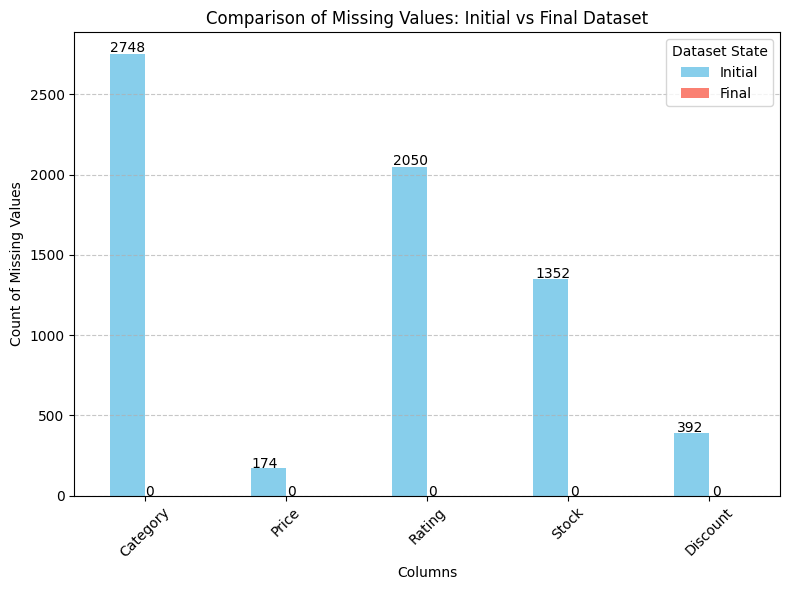

In [113]:
import matplotlib.pyplot as plt

# Calculate missing values for both datasets
initial_missing = df.isnull().sum()
final_missing = df_final.isnull().sum()

# Create a comparison DataFrame for plotting
missing_comparison = pd.DataFrame({
    'Initial': initial_missing,
    'Final': final_missing
})

# Plot the data
ax = missing_comparison.plot(kind='bar', figsize=(8, 6), color=['skyblue', 'salmon'])
plt.title('Comparison of Missing Values: Initial vs Final Dataset')
plt.ylabel('Count of Missing Values')
plt.xlabel('Columns')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title='Dataset State')

# Add labels on top of bars
for p in ax.patches:
    ax.annotate(str(int(p.get_height())), (p.get_x() * 1.005, p.get_height() * 1.005))

plt.tight_layout()
plt.show()